# Домашнее Задание

In [1]:
!pip install datasets

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Далее:

Составим словарь

Создадим датасет WordDataset

И разделим его на train и test

In [11]:
counter = Counter()

for example in dataset['train']['text']:
    processed_text = example.lower().translate(str.maketrans('', '', string.punctuation))

    for word in word_tokenize(processed_text):
        counter[word] += 1

In [21]:
vocab = ['<bos>', '<eos>', '<unk>', '<pad>']
word_threshold = 25

for word, cnt in counter.items():
    if cnt > word_threshold:
        vocab.append(word)

print(len(vocab))
word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

11842


In [55]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.unk_id = word2ind['<unk>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, index):
        processed_text = self.data[index]['text'].lower().translate(str.maketrans('','', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[index]['label']
        }
        return train_sample


    def __len__(self):
        return len(self.data)

In [56]:
def collate_fn_with_padding(input_batch, pad_id=word2ind['<pad>'], max_len=256):
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]

        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [76]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)
eval_dataloader = torch.utils.data.DataLoader(eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [77]:
class MyModel(nn.Module):
    def __init__(self, hidden_dim, vocab_size, num_classes=4, aggregation_type = 'max'):
        super(MyModel, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, hidden_dim)
        self.rnn = torch.nn.GRU(hidden_dim, hidden_dim, batch_first=True, num_layers=5)

        self.linear = torch.nn.Linear(hidden_dim * 2, hidden_dim)
        self.projection = torch.nn.Linear(hidden_dim, num_classes)

        self.not_lin = torch.nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch):
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)

        if self.aggregation_type == 'max':
            agg = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            agg = output.mean(dim=1)

        last_token = output[:,-1,:]
        output = torch.cat([agg, last_token], dim=1)
        output = self.dropout(self.linear(self.not_lin(output)))
        output = self.projection(self.not_lin(output))

        return output

In [78]:
model = MyModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [79]:
def evaluate(model):
  predictions = []
  target = []

  with torch.no_grad():
    for batch in eval_dataloader:
      logits = model(batch['input_ids'])
      predictions.append(logits.argmax(dim=1))
      target.append(batch['label'])

  predictions = torch.cat(predictions)
  target = torch.cat(target)
  accuracy = (predictions == target).float().mean().item()

  return accuracy

In [80]:
num_epoch = 5
eval_steps = len(train_dataloader) / 2

losses_type = {}
accuracies_type = {}

for aggregation_type in tqdm(['max', 'mean']):
  losses = []
  accuracies = []

  model = MyModel(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
  criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
  optimizer = torch.optim.Adam(model.parameters())

  for epoch in tqdm(range(num_epoch)):
    epoch_losses = []
    model.train()
    total_batches = len(train_dataset) // batch_size
    for i, batch in tqdm(enumerate(train_dataloader), total=total_batches):
      optimizer.zero_grad()
      logits = model(batch['input_ids'])
      loss = criterion(logits, batch['label'])
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # обрезает градиенты если они слишком большие
      optimizer.step()

      epoch_losses.append(loss.item())
      if i % eval_steps == 0:
        model.eval()
        accuracies.append(evaluate(model))
        model.train()

    losses.append(sum(epoch_losses) / len(epoch_losses))

  losses_type[aggregation_type] = losses
  accuracies_type[aggregation_type] = accuracies

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

...

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/3750 [00:00<?, ?it/s]

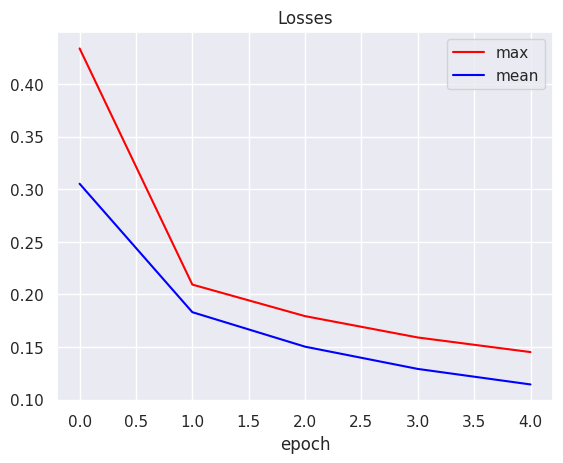

In [81]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

plt.title('Losses')
plt.xlabel('epoch')
plt.legend()
plt.show()

Лучшая accuracy для подхода max: 70.62
Лучшая accuracy для подхода mean: 70.78


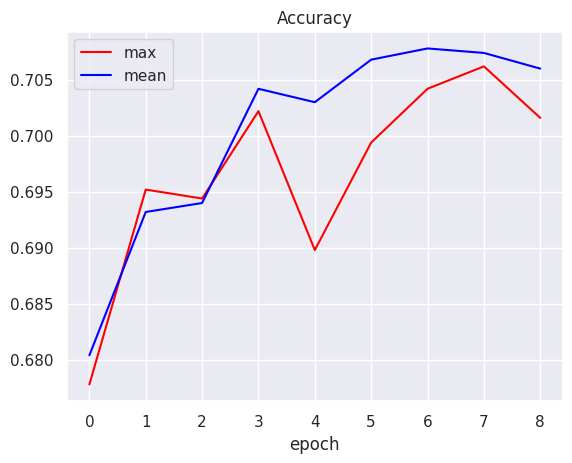

In [82]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(accuracies_type[name][1:])), accuracies_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(accuracies_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()